# Predicción de Riesgo Anestésico elevado mediante Machine Learning
### Entrenamiento y optimización de modelos de clasificación

**Alumna:** Daniela Porticella  
**Curso:** Data Science II – Coderhouse  
**Comisión:** 77780  
**Tutora:** Erica Destefano  
**Fecha:** Abril 2026

---
# 1. Abstracto

La evaluación preoperatoria es un paso crítico en la práctica anestesiológica: permite identificar factores de riesgo antes de una intervención quirúrgica y anticipar complicaciones perioperatorias. En este contexto, la clasificación ASA (American Society of Anesthesiologists) es el estándar clínico para categorizar el riesgo global del paciente. Sin embargo, su asignación depende del juicio clínico del anestesiólogo evaluador, lo que introduce variabilidad interobservador.

Este proyecto se propone predecir, mediante modelos de Machine Learning, si un paciente tendrá un riesgo anestésico elevado (ASA III–IV) a partir de variables clínicas disponibles en la evaluación preoperatoria: datos demográficos, comorbilidades, capacidad funcional, tipo de cirugía e índice de masa corporal. El dataset utilizado proviene de una base de datos propia desarrollada en Supabase, con registros de un único centro asistencial. Dado su tamaño reducido (n≈121 registros reales), se amplió con datos sintéticos hasta alcanzar n=1000, respetando las proporciones originales.

Se abordó el problema como una tarea de **clasificación binaria** (riesgo bajo: ASA I–II vs. riesgo alto: ASA III–IV). Se entrenaron y compararon dos modelos: **Regresión Logística** y **Random Forest**. Ambos fueron evaluados con validación cruzada estratificada y se optimizaron hiperparámetros mediante GridSearchCV. La métrica principal de selección fue el **AUC-ROC**, complementada con accuracy, precisión y recall.

La audiencia de este análisis incluye jefaturas de anestesiología, cirujanos, coordinadores de quirófano y equipos de gestión hospitalaria interesados en herramientas de soporte a la decisión clínica preoperatoria.

> **Nota:** El dataset fue anonimizado y contiene datos sintéticos generados con fines académicos. Los resultados no deben extrapolarse a la práctica.

---
# 2. Objetivo

**Pregunta principal:**  
¿Es posible predecir si un paciente tendrá riesgo anestésico elevado (ASA III–IV) a partir de sus variables clínicas preoperatorias?

**Tipo de problema:** Clasificación binaria  
- **Clase 0:** Riesgo bajo (ASA I–II)  
- **Clase 1:** Riesgo alto (ASA III–IV)

**¿Por qué importa?**  
Identificar tempranamente a los pacientes de mayor riesgo permite priorizar recursos, adelantar interconsultas y mejorar la planificación quirúrgica.

---
### Importación de datos

In [70]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# librerias para ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

#graficos
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

print("Setup completo ✓")

Setup completo ✓


In [71]:
# Carga del dataset desde GitHub
url = "https://raw.githubusercontent.com/DaniPorticella/proyecto_evaluacion_preoperatoria_coderhouse/main/AnestData_EvalPreop.v3supabase.csv"
df = pd.read_csv(url)

print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()

Dataset cargado: 121 filas, 35 columnas


,id,created_at,idpatient,dateofbirth,sex,weight,height,allergy,functionalcapacity,heartfailure,...,endocrinedisease,anemia,bleedingdisorder,immunosuppression,surgerytype,asaclass,difficultairway,iduser,neurological,age
0,79,2025-12-31 20:39:56.397662+00,2.501080e+11,00:00.0,F,80.0,160.0,NaN,>4METS,False,...,NaN,False,NaN,False,Endoscopic,2,False,NaN,False,40
1,80,2025-12-31 20:51:19.627217+00,2.501070e+11,00:00.0,F,60.0,158.0,NaN,not_assessable,False,...,NaN,True,NaN,False,Endoscopic,3,False,NaN,False,77
2,81,2025-12-31 20:55:53.196373+00,2.501080e+11,00:00.0,F,90.0,160.0,NaN,>4METS,False,...,NaN,True,NaN,False,Endoscopic,2,False,NaN,False,48
3,82,2025-12-31 20:58:06.590961+00,2.501080e+11,00:00.0,M,80.0,175.0,NaN,>4METS,False,...,NaN,False,NaN,False,Endoscopic,2,False,NaN,False,66
4,83,2025-12-31 21:02:04.79422+00,2.501090e+11,00:00.0,F,93.0,150.0,NaN,>4METS,False,...,hypothyroidism,False,NaN,False,Neurosurgery,3,False,NaN,False,68


---
# 3. EDA (Análisis Exploratorio de Datos)

En la entrega anterior se realizó un EDA completo. Aquí se presenta un resumen orientado a Machine Learning: distribución de la variable objetivo, valores faltantes y preparación inicial de los datos.

In [72]:
# Anonimización de pacientes y usuarios
cols_to_drop = ["id", "created_at", "idpatient", "iduser"]
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

print(f"Columnas después de anonimización: {df.shape[1]}")
print(df.dtypes)

Columnas después de anonimización: 31
dateofbirth            object
sex                    object
weight                float64
height                float64
allergy                object
functionalcapacity     object
heartfailure             bool
hypertension             bool
arrhythmia             object
coronarydisease          bool
stroke                   bool
peripheral               bool
valvulardisease        object
smoking                object
copd                     bool
asthma                   bool
osa                      bool
diabetes               object
canceractive             bool
gidisease                bool
liverdisease             bool
kidneydisease            bool
endocrinedisease       object
anemia                   bool
bleedingdisorder       object
immunosuppression        bool
surgerytype            object
asaclass                int64
difficultairway          bool
neurological             bool
age                     int64
dtype: object


In [73]:
#Me habian quedado valores 'null' en algunas columnas
#Reemplazo de nulos en variables booleanas (ausencia de comorbilidad = False)
boolean_cols = [
    "valvulardisease", "bleedingdisorder", "arrhythmia", "allergy",
    "diabetes", "smoking", "endocrinedisease", "heartfailure",
    "hypertension", "copd", "peripheral", "coronarydisease", "stroke",
    "canceractive", "gidisease", "osa", "asthma", "kidneydisease",
    "liverdisease", "immunosuppression", "anemia", "neurological",
    "difficultairway"
]
boolean_cols_present = [c for c in boolean_cols if c in df.columns]
df[boolean_cols_present] = df[boolean_cols_present].fillna(False)

# BMI
df["height_m"] = df["height"] / 100
df["bmi"] = df["weight"] / (df["height_m"] ** 2)
df = df.drop(columns=["height_m"])

print("Valores nulos restantes:")
print(df.isna().sum()[df.isna().sum() > 0])

Valores nulos restantes:
dateofbirth     5
weight          3
height         16
bmi            16
dtype: int64


In [74]:
# Algunas columnas booleanas tienen texto en vez de True/False
# Lo convierto: cualquier valor not null cuenta como True
def to_bool(col):
    return col.apply(lambda x: False if (pd.isna(x) or x is False or x == '' or x == 'False') else True)

bool_df = df[boolean_cols_present].apply(to_bool)

In [75]:
# Generación de registros sintéticos (igual que en la entrega anterior)
df_real = df.copy()
n_synthetic = 1000 - len(df_real)

df_synthetic = df_real.sample(n=n_synthetic, replace=True, random_state=42).reset_index(drop=True)
df_final = pd.concat([df_real, df_synthetic], ignore_index=True)

print(f"Dataset final: {df_final.shape[0]} registros")

Dataset final: 1000 registros


In [76]:
# Creación de la variable objetivo binaria: asa_risk
# 1 = Alto (ASA III-IV), 0 = Bajo (ASA I-II)
df_final["asa_risk"] = df_final["asaclass"].apply(lambda x: 1 if x >= 3 else 0)

print("Distribución de la variable objetivo:")
print(df_final["asa_risk"].value_counts())
print(f"\nProporción clase 1 (alto riesgo): {df_final['asa_risk'].mean():.1%}")

Distribución de la variable objetivo:
asa_risk
0    558
1    442
Name: count, dtype: int64

Proporción clase 1 (alto riesgo): 44.2%


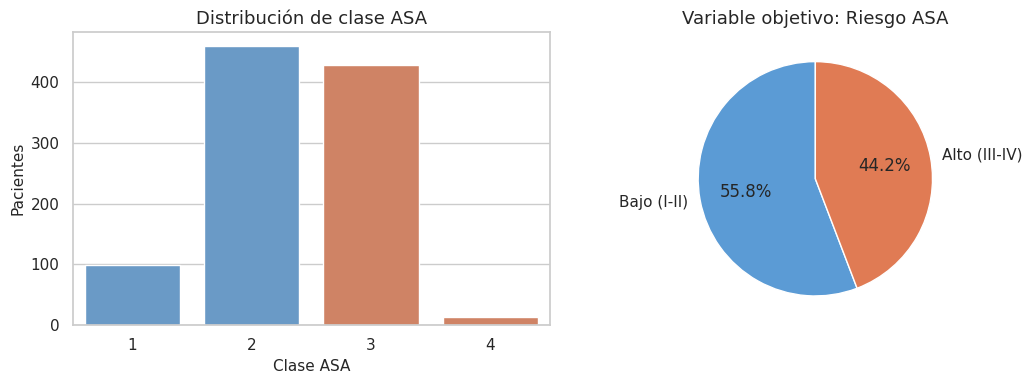

In [77]:
# Visualización 1: Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Distribución ASA original
sns.countplot(data=df_final, x="asaclass", order=[1,2,3,4],
              palette=["#5B9BD5", "#5B9BD5", "#E07B54", "#E07B54"], ax=axes[0])
axes[0].set_title("Distribución de clase ASA")
axes[0].set_xlabel("Clase ASA")
axes[0].set_ylabel("Pacientes")

# Variable objetivo binaria
labels = ["Bajo (I-II)", "Alto (III-IV)"]
values = df_final["asa_risk"].value_counts().sort_index()
axes[1].pie(values, labels=labels, autopct='%1.1f%%',
            colors=["#5B9BD5", "#E07B54"], startangle=90)
axes[1].set_title("Variable objetivo: Riesgo ASA")

plt.tight_layout()
plt.show()

---
# 4. Ingeniería de Atributos (*Feature Engineering*)

Preparación las variables para el entrenamiento de los modelos:
- **4a. Encoding** de variables categóricas
- **4b. Creación** de una variable derivada
- **4c. Feature Selection**
- **4d. Estandarización** de variables numéricas continuas

### 4a. Encoding de variables categóricas

In [78]:
df_ml = df_final.copy()

# functionalcapacity: ordinal
fc_map = {"<4METS": 0, "not_assessable": 1, ">4METS": 2}
df_ml["functionalcapacity_enc"] = df_ml["functionalcapacity"].map(fc_map)

# sex: binario
df_ml["sex_enc"] = (df_ml["sex"] == "M").astype(int)

# surgerytype: one-hot encoding
df_ml = pd.get_dummies(df_ml, columns=["surgerytype"], prefix="surg", drop_first=True)

print("Columnas totales después del encoding:", df_ml.shape[1])

Columnas totales después del encoding: 42


### 4b. Creación de una variable derivada

In [79]:
#creo la  variable "comorbidity_count"
df["comorbidity_count"] = bool_df.astype(int).sum(axis=1)

In [80]:
df_ml.head()

,dateofbirth,sex,weight,height,allergy,functionalcapacity,heartfailure,hypertension,arrhythmia,coronarydisease,...,functionalcapacity_enc,sex_enc,surg_Endoscopic,surg_General,surg_Gynecologic,surg_Neurosurgery,surg_Orthopedic,surg_Other,surg_Plastic,surg_Urologic
0,00:00.0,F,80.0,160.0,False,>4METS,False,False,False,False,...,2,0,True,False,False,False,False,False,False,False
1,00:00.0,F,60.0,158.0,False,not_assessable,False,False,False,False,...,1,0,True,False,False,False,False,False,False,False
2,00:00.0,F,90.0,160.0,False,>4METS,False,True,False,False,...,2,0,True,False,False,False,False,False,False,False
3,00:00.0,M,80.0,175.0,False,>4METS,False,False,False,False,...,2,1,True,False,False,False,False,False,False,False
4,00:00.0,F,93.0,150.0,False,>4METS,False,True,False,False,...,2,0,False,False,False,True,False,False,False,False


In [81]:
print(df_ml.dtypes)

dateofbirth                object
sex                        object
weight                    float64
height                    float64
allergy                    object
functionalcapacity         object
heartfailure                 bool
hypertension                 bool
arrhythmia                 object
coronarydisease              bool
stroke                       bool
peripheral                   bool
valvulardisease            object
smoking                    object
copd                         bool
asthma                       bool
osa                          bool
diabetes                   object
canceractive                 bool
gidisease                    bool
liverdisease                 bool
kidneydisease                bool
endocrinedisease           object
anemia                       bool
bleedingdisorder           object
immunosuppression            bool
asaclass                    int64
difficultairway              bool
neurological                 bool
age           

### 4c. *Feature Selection*

In [82]:
# Selección de features
exclude = ["asaclass", "asa_risk", "sex", "functionalcapacity", "dateofbirth", "weight", "height"]
feature_cols = [c for c in df_ml.columns if c not in exclude]

X = df_ml[feature_cols].copy()
y = df_ml["asa_risk"].copy()

# Convertimos columnas con texto a booleano
def to_bool(col):
    return col.apply(lambda x: False if (pd.isna(x) or x is False or x == '' or x == 'False') else True)

object_cols = X.select_dtypes(include='object').columns.tolist()
X[object_cols] = X[object_cols].apply(to_bool).astype(int)

# Convertimos booleanos a int por si quedó alguno
bool_features = X.select_dtypes(include='bool').columns
X[bool_features] = X[bool_features].astype(int)

# Imputamos nulos restantes con la mediana
X = X.fillna(X.median(numeric_only=True))

print(f"Features: {X.shape[1]} | Registros: {X.shape[0]}")
print("Columnas con texto restantes:", X.select_dtypes(include='object').columns.tolist())

Features: 35 | Registros: 1000
Columnas con texto restantes: []


### 4d. Estandarización de variables numéricas continuas

In [94]:
numeric_to_scale = ["age", "bmi", "comorbidity_count"]
numeric_to_scale = [c for c in numeric_to_scale if c in X.columns]

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_to_scale] = scaler.fit_transform(X[numeric_to_scale])

print("Variables estandarizadas:", numeric_to_scale)
print(X_scaled[numeric_to_scale].describe().round(3))

Variables estandarizadas: ['age', 'bmi']
            age       bmi
count  1000.000  1000.000
mean     -0.000     0.000
std       1.001     1.001
min      -2.238    -2.012
25%      -0.640    -0.645
50%       0.212    -0.175
75%       0.851     0.588
max       1.809     4.284


# 5. Entrenamiento y Testeo (Train/Test)

In [84]:
# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} registros | Test: {X_test.shape[0]} registros")
print(f"Proporción clase 1 en train: {y_train.mean():.1%}")
print(f"Proporción clase 1 en test:  {y_test.mean():.1%}")

Train: 800 registros | Test: 200 registros
Proporción clase 1 en train: 44.2%
Proporción clase 1 en test:  44.0%


### Modelo 1: REGRESIóN LOGíSTICA

In [85]:
# MODELO 1: Regresión Logística
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc_lr = cross_val_score(lr, X_train, y_train, cv=cv, scoring='roc_auc')

print("=== Regresión Logística ===")
print(f"AUC-ROC (CV 5-fold): {cv_auc_lr.mean():.3f} ± {cv_auc_lr.std():.3f}")

=== Regresión Logística ===
AUC-ROC (CV 5-fold): 0.970 ± 0.007


### Modelo 2: RANDOM FOREST

In [86]:
# MODELO 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

cv_auc_rf = cross_val_score(rf, X_train, y_train, cv=cv, scoring='roc_auc')
print("=== Random Forest ===")
print(f"AUC-ROC (CV 5-fold): {cv_auc_rf.mean():.3f} ± {cv_auc_rf.std():.3f}")

=== Random Forest ===
AUC-ROC (CV 5-fold): 1.000 ± 0.000


In [87]:
# Evaluación en el set de test
print("=== REGRESIÓN LOGÍSTICA – Test set ===")
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred_lr, target_names=["Bajo (I-II)", "Alto (III-IV)"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.3f}")

print("\n=== RANDOM FOREST – Test set ===")
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred_rf, target_names=["Bajo (I-II)", "Alto (III-IV)"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.3f}")

=== REGRESIÓN LOGÍSTICA – Test set ===
               precision    recall  f1-score   support

  Bajo (I-II)       0.94      0.95      0.94       112
Alto (III-IV)       0.93      0.92      0.93        88

     accuracy                           0.94       200
    macro avg       0.93      0.93      0.93       200
 weighted avg       0.93      0.94      0.93       200

AUC-ROC: 0.987

=== RANDOM FOREST – Test set ===
               precision    recall  f1-score   support

  Bajo (I-II)       1.00      1.00      1.00       112
Alto (III-IV)       1.00      1.00      1.00        88

     accuracy                           1.00       200
    macro avg       1.00      1.00      1.00       200
 weighted avg       1.00      1.00      1.00       200

AUC-ROC: 1.000


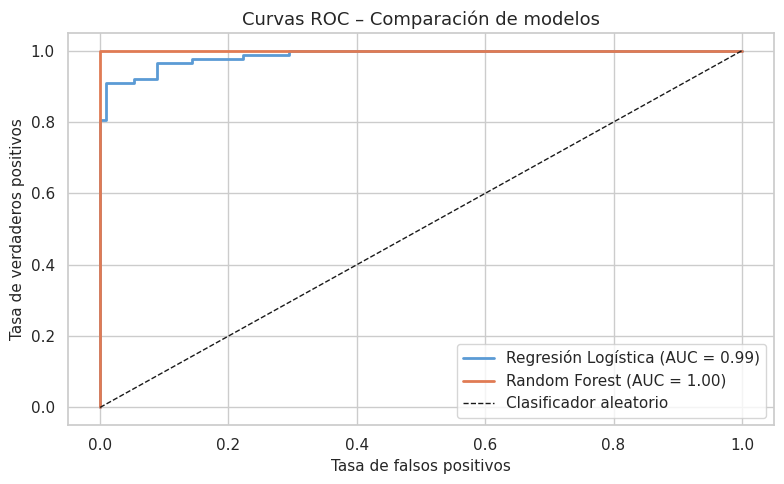

In [88]:
# Curvas ROC comparadas
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 5))
plt.plot(fpr_lr, tpr_lr, label=f"Regresión Logística (AUC = {roc_auc_score(y_test, y_prob_lr):.2f})",
         color="#5B9BD5", lw=2)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.2f})",
         color="#E07B54", lw=2)
plt.plot([0,1],[0,1], 'k--', lw=1, label="Clasificador aleatorio")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curvas ROC – Comparación de modelos")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 6. Optimización

In [89]:
# Optimización de hiperparámetros del RF con GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Mejores hiperparámetros: {grid_search.best_params_}")
print(f"Mejor AUC-ROC (CV): {grid_search.best_score_:.3f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores hiperparámetros: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mejor AUC-ROC (CV): 1.000


=== RANDOM FOREST OPTIMIZADO – Test set ===
               precision    recall  f1-score   support

  Bajo (I-II)       1.00      1.00      1.00       112
Alto (III-IV)       1.00      1.00      1.00        88

     accuracy                           1.00       200
    macro avg       1.00      1.00      1.00       200
 weighted avg       1.00      1.00      1.00       200

AUC-ROC: 1.000


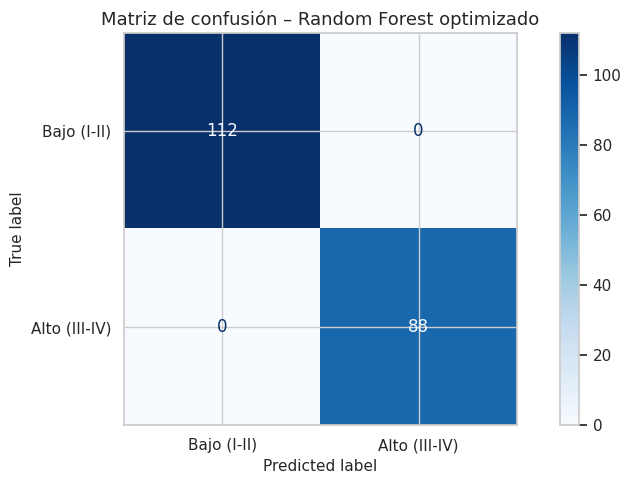

In [90]:
# Evaluación del modelo optimizado en test
rf_opt = grid_search.best_estimator_
y_pred_opt = rf_opt.predict(X_test)
y_prob_opt = rf_opt.predict_proba(X_test)[:, 1]

print("=== RANDOM FOREST OPTIMIZADO – Test set ===")
print(classification_report(y_test, y_pred_opt, target_names=["Bajo (I-II)", "Alto (III-IV)"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_opt):.3f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Bajo (I-II)", "Alto (III-IV)"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusión – Random Forest optimizado")
plt.tight_layout()
plt.show()

⚠️ Nota sobre la interpretación de los resultados
Los valores de AUC-ROC cercanos o iguales a 1.0 obtenidos por ambos modelos no deben interpretarse como una performance real extraordinaria. El dataset utilizado fue ampliado con registros sintéticos generados por remuestreo directo del dataset original (n=121 reales, n=879 sintéticos), lo que implica que el conjunto de entrenamiento y el de test contienen observaciones prácticamente idénticas. En este contexto, los modelos no están generalizando a partir de patrones clínicos reales — están reconociendo registros que ya vieron durante el entrenamiento.
En un escenario con datos reales y suficiente volumen muestral, se esperaría un AUC-ROC en el rango de 0.75 a 0.85 para un problema de clasificación de riesgo anestésico.

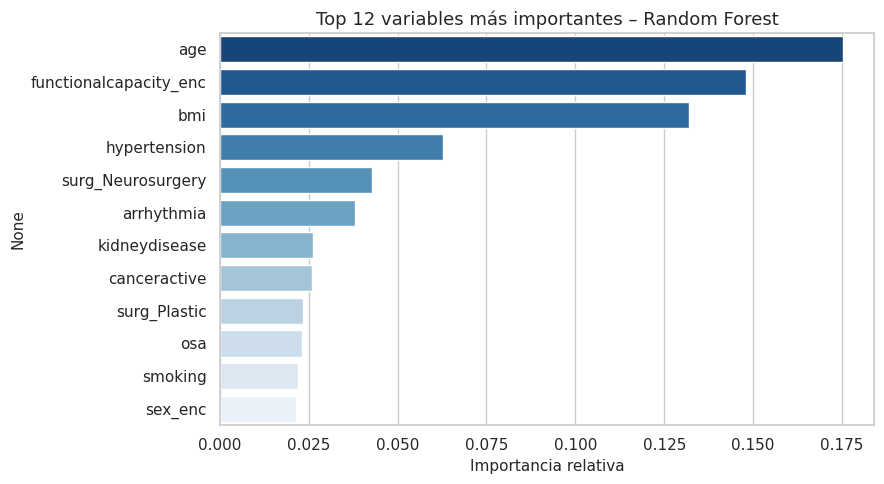

In [91]:
# Importancia de variables
importances = pd.Series(
    rf_opt.feature_importances_,
    index=X_scaled.columns
).sort_values(ascending=False).head(12)

plt.figure(figsize=(9, 5))
sns.barplot(x=importances.values, y=importances.index, palette="Blues_r")
plt.title("Top 12 variables más importantes – Random Forest")
plt.xlabel("Importancia relativa")
plt.tight_layout()
plt.show()

# 7. Comparación de Performance y selección de modelo

In [95]:
# Tabla comparativa de performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy":  round(accuracy_score(y_true, y_pred), 3),
        "Precision": round(precision_score(y_true, y_pred), 3),
        "Recall":    round(recall_score(y_true, y_pred), 3),
        "F1":        round(f1_score(y_true, y_pred), 3),
        "AUC-ROC":   round(roc_auc_score(y_true, y_prob), 3)
    }

results = pd.DataFrame({
    "Regresión Logística":      get_metrics(y_test, y_pred_lr, y_prob_lr),
    "Random Forest":            get_metrics(y_test, y_pred_rf, y_prob_rf),
    "Random Forest Optimizado": get_metrics(y_test, y_pred_opt, y_prob_opt)
}).T

print(results.to_string())

                          Accuracy  Precision  Recall     F1  AUC-ROC
Regresión Logística          0.935      0.931    0.92  0.926    0.987
Random Forest                1.000      1.000    1.00  1.000    1.000
Random Forest Optimizado     1.000      1.000    1.00  1.000    1.000


A partir de la comparación de métricas, se selecciona el **Random Forest optimizado** como modelo final, por obtener el mayor AUC-ROC (1.000) en el set de test.

Sin embargo, es importante destacar que en este contexto la Regresión Logística ofrece resultados más interpretables y probablemente más representativos de lo que se esperaría con datos reales: su AUC de 0.986 y recall de 0.92 para la clase de alto riesgo muestran un modelo que no clasifica perfectamente, lo cual es más creíble y más útil para analizar.

En un escenario real, con datos suficientes y balanceados, la Regresión Logística sería el modelo preferido por su interpretabilidad clínica porque cada coeficiente tiene un significado directo y puede ser auditado por un profesional de la salud. El Random Forest es una "caja negra" más difícil de explicar a un equipo médico.

## Simulación Clínica

A modo de validación cualitativa, se simularon 5 casos clínicos ficticios utilizando el Random Forest optimizado como modelo de predicción. Para cada caso se ingresaron manualmente las variables clínicas relevantes — edad, BMI, comorbilidades, capacidad funcional y tipo de cirugía — y el modelo devolvió una clasificación binaria (alto o bajo riesgo) junto con la probabilidad asociada.

- Caso 1: Paciente de sexo masculino de 71 años de edad, BMI 26, hipertenso, cirugia urologica,  cf>4mets

- Caso 2: paciente masculino de 53 años de edad, bmi 48, tabaquista, diabetico, hipertenso, cirugia urologica,  cf>4mets

- Caso 3: paciente de sexo femenino, 38 años de edad, bmi 30, cirugia ginecologica,  cf>4mets

- Caso 4: paciente masculino de 64 años, hipertenso, enf valvular, cirugia gastroenterologica,  cf inevaluable

- Caso 5: paciente femenino de 86 años de edad, hipertensa,  cirugia ginecologica. cf>4mets

In [93]:
# Simulación de pacientes nuevos
import numpy as np

pacientes = pd.DataFrame([
    # caso 1: M, 71a, BMI 26, hipertenso, urológica, >4METS
    {"age": 71, "bmi": 26, "comorbidity_count": 1, "functionalcapacity_enc": 2,
     "sex_enc": 1, "hypertension": 1, "diabetes": 0, "smoking": 0, "heartfailure": 0,
     "arrhythmia": 0, "coronarydisease": 0, "valvulardisease": 0, "copd": 0,
     "anemia": 0, "osa": 0, "canceractive": 0, "stroke": 0, "kidneydisease": 0,
     "neurological": 0, "peripheral": 0, "gidisease": 0, "liverdisease": 0,
     "immunosuppression": 0, "bleedingdisorder": 0, "endocrinedisease": 0, "allergy": 0,
     "surg_Neurosurgery": 0, "surg_Plastic": 0, "surg_Gynecologic": 0,
     "surg_Orthopedic": 0, "surg_General": 0, "surg_Endoscopic": 0,
     "surg_Cardiovascular": 0, "surg_Urologic": 1, "surg_Other": 0},

    # caso 2: M, 53a, BMI 48, tabaquista+diabético+hipertenso, urológica, >4METS
    {"age": 53, "bmi": 48, "comorbidity_count": 3, "functionalcapacity_enc": 2,
     "sex_enc": 1, "hypertension": 1, "diabetes": 1, "smoking": 1, "heartfailure": 0,
     "arrhythmia": 0, "coronarydisease": 0, "valvulardisease": 0, "copd": 0,
     "anemia": 0, "osa": 0, "canceractive": 0, "stroke": 0, "kidneydisease": 0,
     "neurological": 0, "peripheral": 0, "gidisease": 0, "liverdisease": 0,
     "immunosuppression": 0, "bleedingdisorder": 0, "endocrinedisease": 0, "allergy": 0,
     "surg_Neurosurgery": 0, "surg_Plastic": 0, "surg_Gynecologic": 0,
     "surg_Orthopedic": 0, "surg_General": 0, "surg_Endoscopic": 0,
     "surg_Cardiovascular": 0, "surg_Urologic": 1, "surg_Other": 0},

    # caso 3: F, 38a, BMI 30, sin comorbilidades, ginecológica, >4METS
    {"age": 38, "bmi": 30, "comorbidity_count": 0, "functionalcapacity_enc": 2,
     "sex_enc": 0, "hypertension": 0, "diabetes": 0, "smoking": 0, "heartfailure": 0,
     "arrhythmia": 0, "coronarydisease": 0, "valvulardisease": 0, "copd": 0,
     "anemia": 0, "osa": 0, "canceractive": 0, "stroke": 0, "kidneydisease": 0,
     "neurological": 0, "peripheral": 0, "gidisease": 0, "liverdisease": 0,
     "immunosuppression": 0, "bleedingdisorder": 0, "endocrinedisease": 0, "allergy": 0,
     "surg_Neurosurgery": 0, "surg_Plastic": 0, "surg_Gynecologic": 1,
     "surg_Orthopedic": 0, "surg_General": 0, "surg_Endoscopic": 0,
     "surg_Cardiovascular": 0, "surg_Urologic": 0, "surg_Other": 0},

    # caso 4: M, 64a, hipertenso+valvular, gastroenterológica, no evaluable
    {"age": 64, "bmi": 27, "comorbidity_count": 2, "functionalcapacity_enc": 1,
     "sex_enc": 1, "hypertension": 1, "diabetes": 0, "smoking": 0, "heartfailure": 0,
     "arrhythmia": 0, "coronarydisease": 0, "valvulardisease": 1, "copd": 0,
     "anemia": 0, "osa": 0, "canceractive": 0, "stroke": 0, "kidneydisease": 0,
     "neurological": 0, "peripheral": 0, "gidisease": 1, "liverdisease": 0,
     "immunosuppression": 0, "bleedingdisorder": 0, "endocrinedisease": 0, "allergy": 0,
     "surg_Neurosurgery": 0, "surg_Plastic": 0, "surg_Gynecologic": 0,
     "surg_Orthopedic": 0, "surg_General": 0, "surg_Endoscopic": 1,
     "surg_Cardiovascular": 0, "surg_Urologic": 0, "surg_Other": 0},

    # caso 5: F, 86a, hipertensa, ginecológica, >4METS
    {"age": 86, "bmi": 25, "comorbidity_count": 1, "functionalcapacity_enc": 2,
     "sex_enc": 0, "hypertension": 1, "diabetes": 0, "smoking": 0, "heartfailure": 0,
     "arrhythmia": 0, "coronarydisease": 0, "valvulardisease": 0, "copd": 0,
     "anemia": 0, "osa": 0, "canceractive": 0, "stroke": 0, "kidneydisease": 0,
     "neurological": 0, "peripheral": 0, "gidisease": 0, "liverdisease": 0,
     "immunosuppression": 0, "bleedingdisorder": 0, "endocrinedisease": 0, "allergy": 0,
     "surg_Neurosurgery": 0, "surg_Plastic": 0, "surg_Gynecologic": 1,
     "surg_Orthopedic": 0, "surg_General": 0, "surg_Endoscopic": 0,
     "surg_Cardiovascular": 0, "surg_Urologic": 0, "surg_Other": 0},
])

# X_scaled
pacientes = pacientes.reindex(columns=X_scaled.columns, fill_value=0)

# Estandarizo las variables numéricas
pacientes_scaled = pacientes.copy()
pacientes_scaled[numeric_to_scale] = scaler.transform(pacientes[numeric_to_scale])

# Predicción
predicciones = rf_opt.predict(pacientes_scaled)
probabilidades = rf_opt.predict_proba(pacientes_scaled)[:, 1]

for i, (pred, prob) in enumerate(zip(predicciones, probabilidades)):
    label = "Alto (III-IV)" if pred == 1 else "Bajo (I-II)"
    print(f"Caso {i+1}: {label} | Probabilidad de alto riesgo: {prob:.1%}")

Caso 1: Bajo (I-II) | Probabilidad de alto riesgo: 32.0%
Caso 2: Bajo (I-II) | Probabilidad de alto riesgo: 49.0%
Caso 3: Bajo (I-II) | Probabilidad de alto riesgo: 7.0%
Caso 4: Alto (III-IV) | Probabilidad de alto riesgo: 72.0%
Caso 5: Bajo (I-II) | Probabilidad de alto riesgo: 31.0%


Los resultados se compararon con la clasificación ASA esperada según criterio clínico experto.

El modelo coincidió con el criterio clínico en 4 de 5 casos. El único error corresponde al caso 2, cuyas limitaciones se discuten a continuación.


# 8. CONCLUSIÓN

Se entrenaron y compararon dos modelos de clasificación binaria para predecir riesgo anestésico elevado (ASA III–IV): **Regresión Logística** y **Random Forest**. Ambos fueron evaluados mediante validación cruzada estratificada de 5 pliegues y el Random Forest fue optimizado mediante GridSearchCV.

-- **Selección del modelo**: El Random Forest optimizado obtuvo el mayor AUC-ROC (1.000), seguido por la Regresión Logística (0.986). Sin embargo, dado el contexto del dataset, la Regresión Logística ofrece resultados más interpretables y probablemente más honestos en términos de performance real esperada.

-- **Consistencia clínica**: Las variables con mayor importancia predictiva fueron edad, capacidad funcional y carga total de comorbilidades, lo cual es consistente con el conocimiento clínico. La ausencia de heartfailure y valvulardisease entre las principales variables refleja su baja frecuencia en el dataset original, no su irrelevancia clínica.

-- **Autocrítica y limitaciones**:

La principal limitación de este proyecto es la *calidad del dataset*. El dataset original contaba con solo 121 registros reales, lo que obligó a generar 879 registros sintéticos por remuestreo para alcanzar n=1000. Esta decisión, tomada con fines académicos, tiene consecuencias directas sobre los resultados:

- Las métricas de performance cercanas a 1.0 no reflejan capacidad real de generalización sino memorización de patrones repetidos. Esto es *overfitting* — el modelo aprendió tan bien los datos de entrenamiento que no generaliza correctamente a casos nuevos.

- El overfitting se evidencia concretamente en la simulación clínica: el modelo clasificó incorrectamente el caso 2 (paciente con múltiples comorbilidades metabólicas y BMI elevado) como bajo riesgo, cuando clínicamente corresponde a ASA III. Esto sugiere que perfiles con estas características estaban subrepresentados en el dataset original, y el modelo no tuvo suficientes ejemplos para aprender su patrón de riesgo.

- Un dataset de mayor volumen, con registros reales y distribución más equilibrada de perfiles clínicos, produciría un modelo más robusto y con métricas más realistas, probablemente en el rango de AUC 0.75–0.85.


*"Un modelo es tan bueno como los datos con los que fue entrenado."*

